In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the section analysis results
df = pd.read_csv('section_analysis_results.csv')

# Convert Time to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Extract additional temporal features
df['Hour'] = df['Time'].dt.hour
df['DayOfWeek'] = df['Time'].dt.dayofweek
df['Month'] = df['Time'].dt.month

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


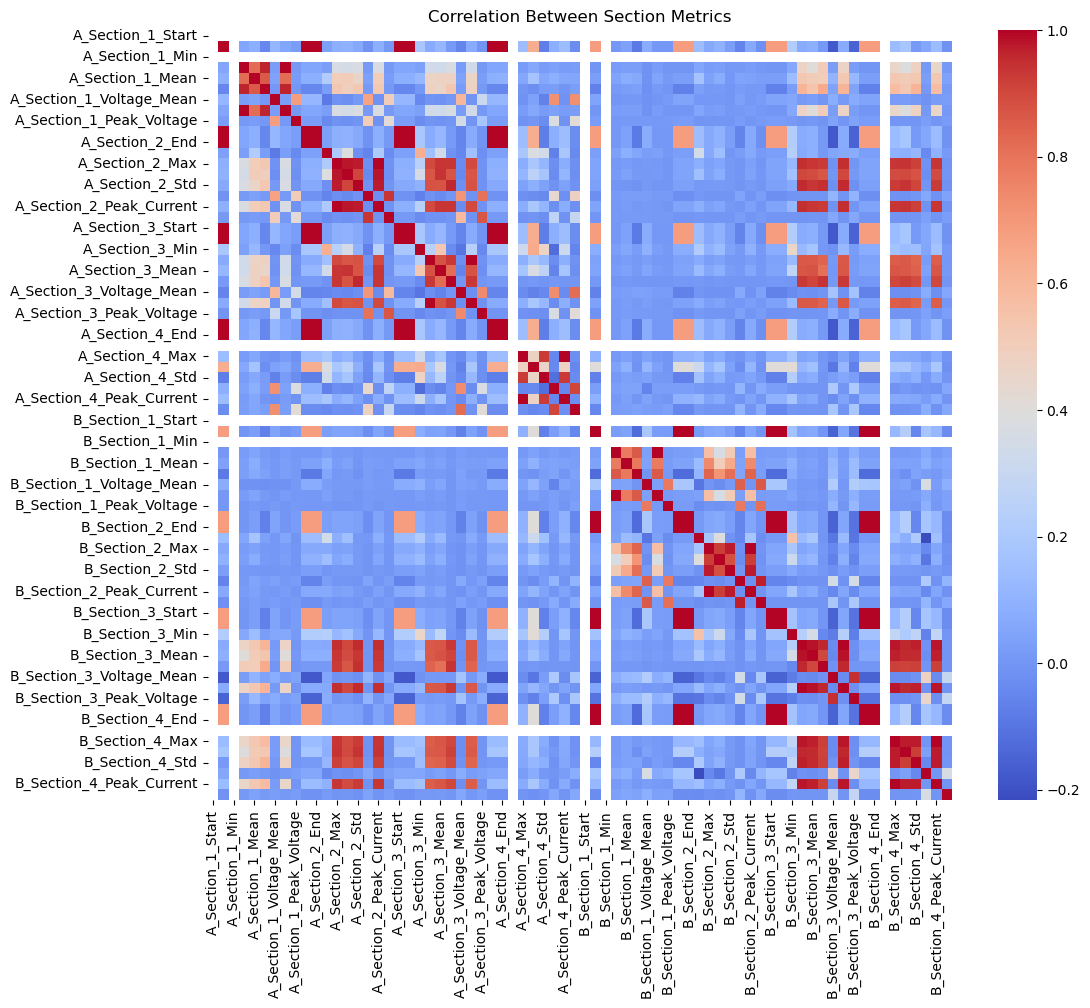

In [2]:
# Summary statistics for all sections
section_columns = [col for col in df.columns if 'Section_' in col]
df[section_columns].describe().T

# Correlation matrix
corr_matrix = df[section_columns].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Section Metrics')
plt.show()

## Location-based analysis 

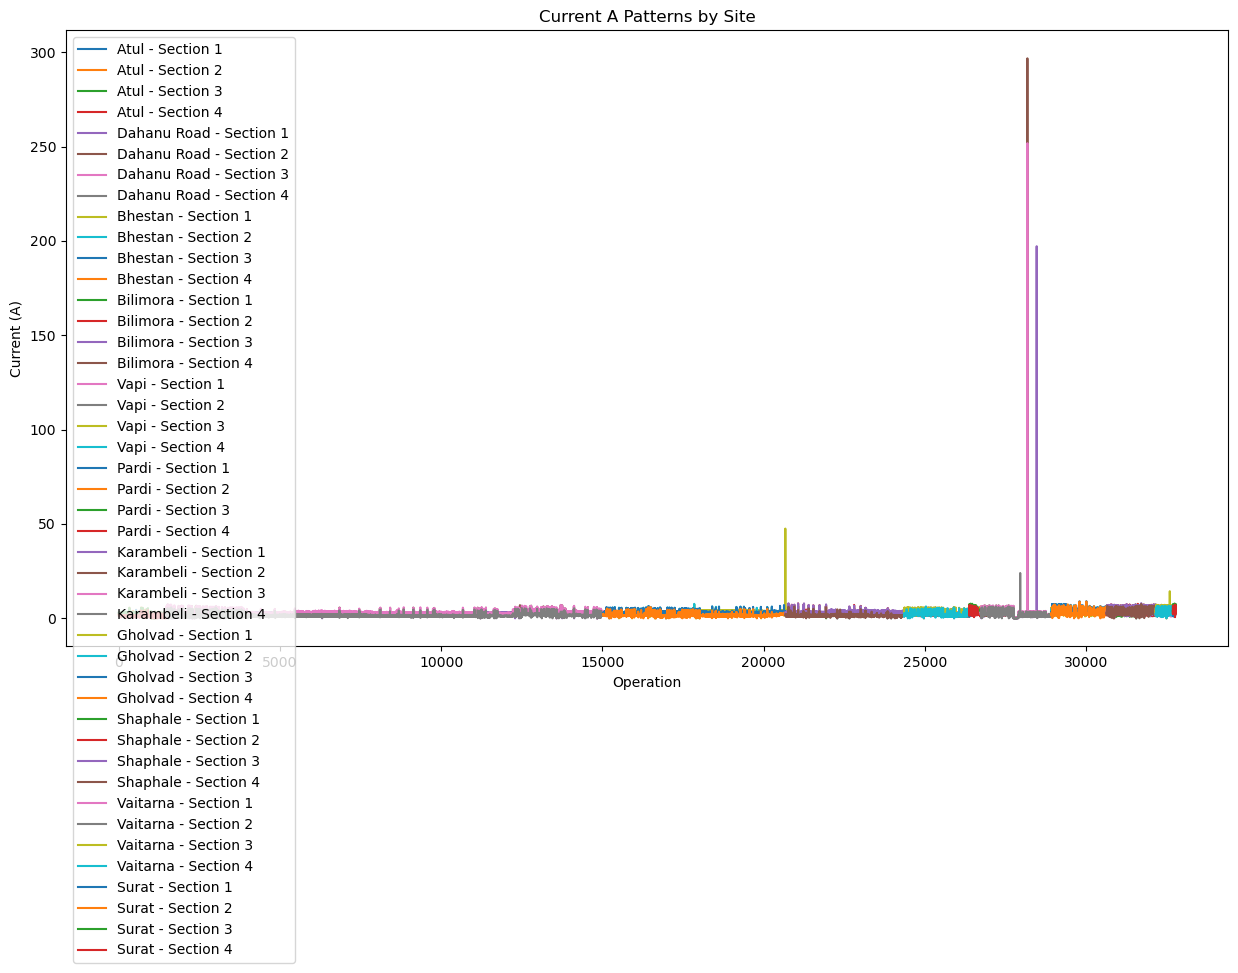

In [3]:
# Group by Site and Point Machine
site_analysis = df.groupby(['Site Name', 'Point Machine Name']).agg({
    'A_Section_1_Mean': 'mean',
    'A_Section_2_Mean': 'mean',
    'A_Section_3_Mean': 'mean',
    'A_Section_4_Mean': 'mean',
    'B_Section_1_Mean': 'mean',
    'B_Section_2_Mean': 'mean',
    'B_Section_3_Mean': 'mean',
    'B_Section_4_Mean': 'mean',
    'Total Samples A': 'mean',
    'Total Samples B': 'mean'
}).reset_index()

# Visualize current patterns by site
plt.figure(figsize=(15,8))
for site in df['Site Name'].unique():
    site_data = df[df['Site Name'] == site]
    plt.plot(site_data['A_Section_1_Mean'], label=f'{site} - Section 1')
    plt.plot(site_data['A_Section_2_Mean'], label=f'{site} - Section 2')
    plt.plot(site_data['A_Section_3_Mean'], label=f'{site} - Section 3')
    plt.plot(site_data['A_Section_4_Mean'], label=f'{site} - Section 4')
plt.legend()
plt.title('Current A Patterns by Site')
plt.xlabel('Operation')
plt.ylabel('Current (A)')
plt.show()

## Analysis for Surat site 

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

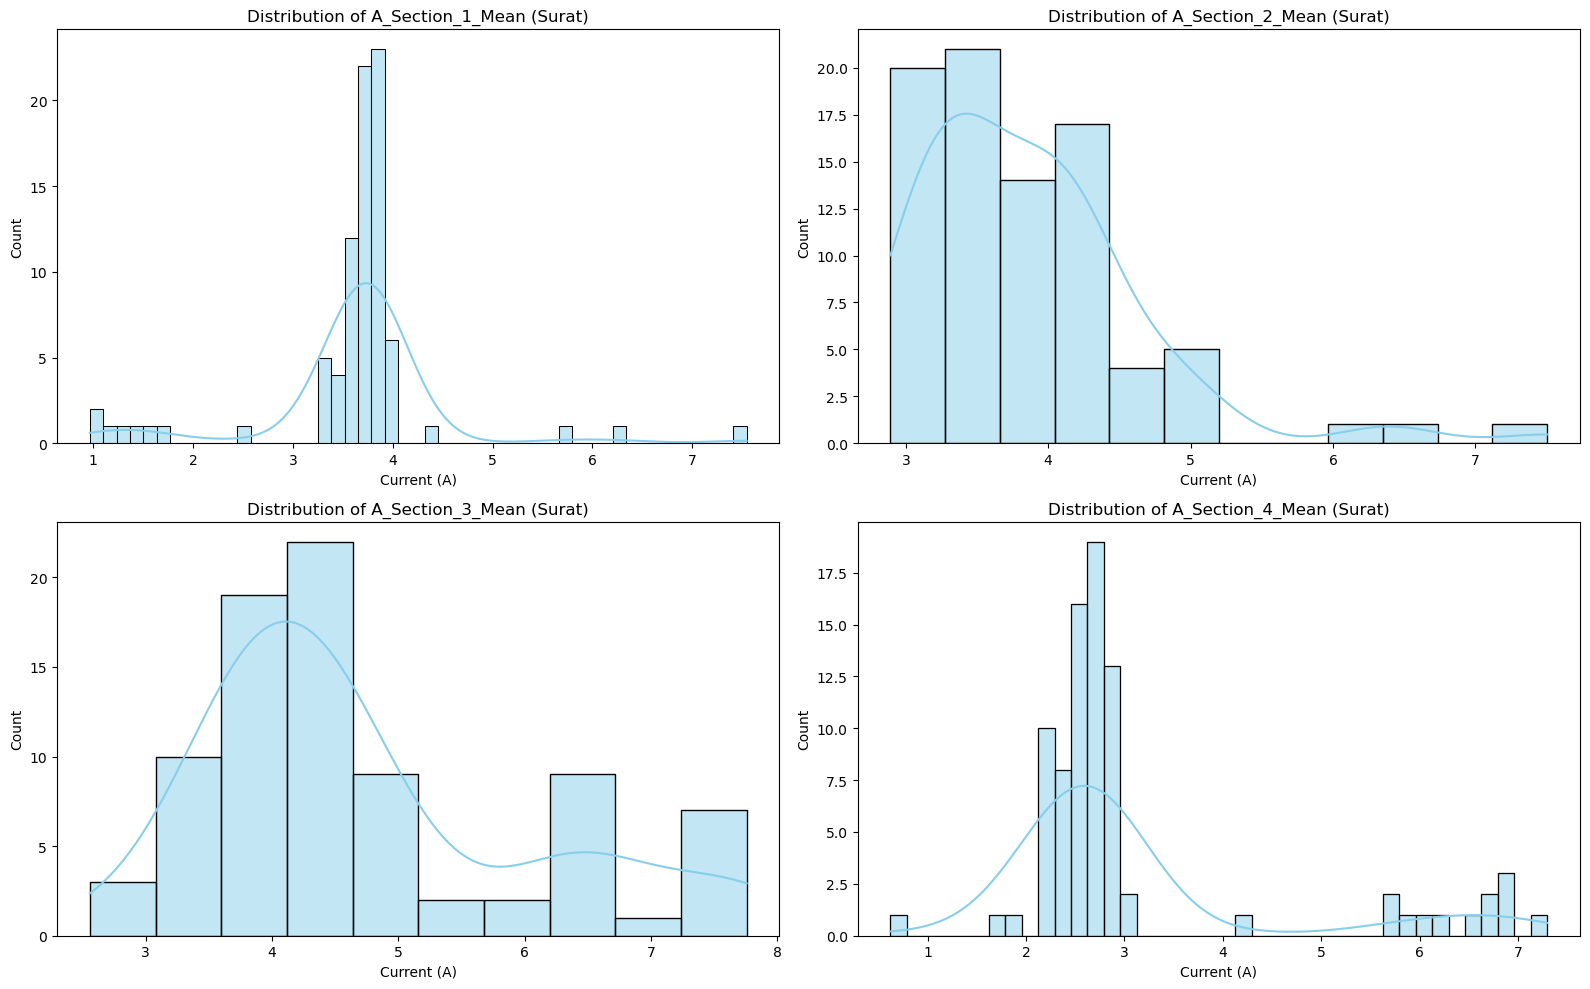

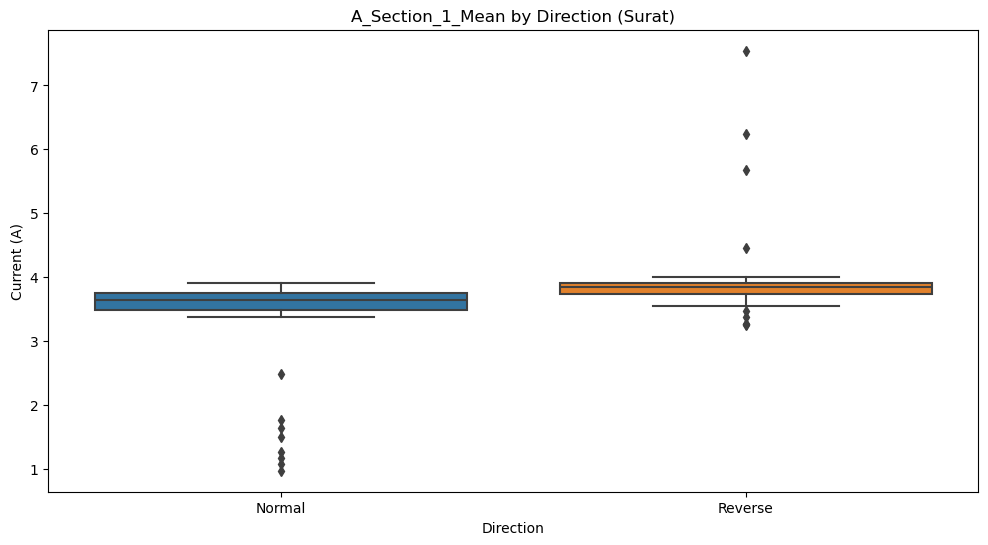

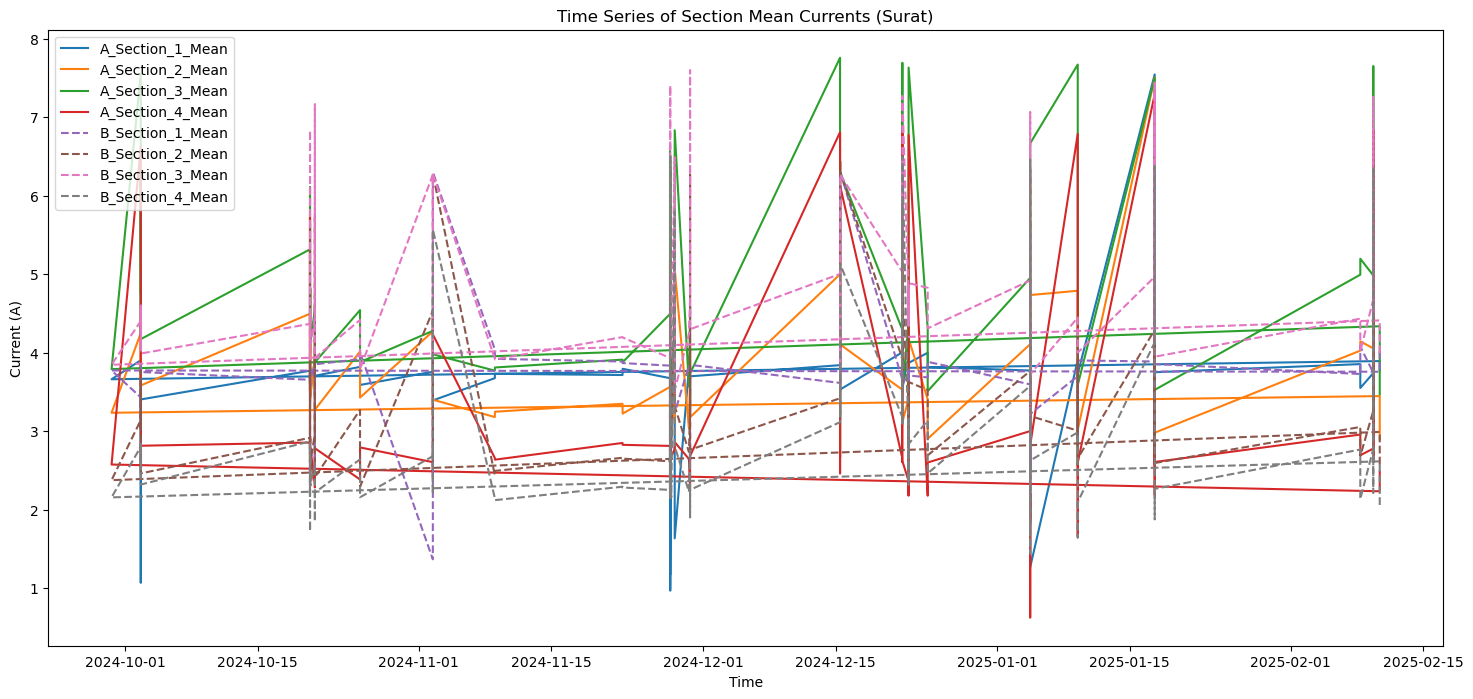

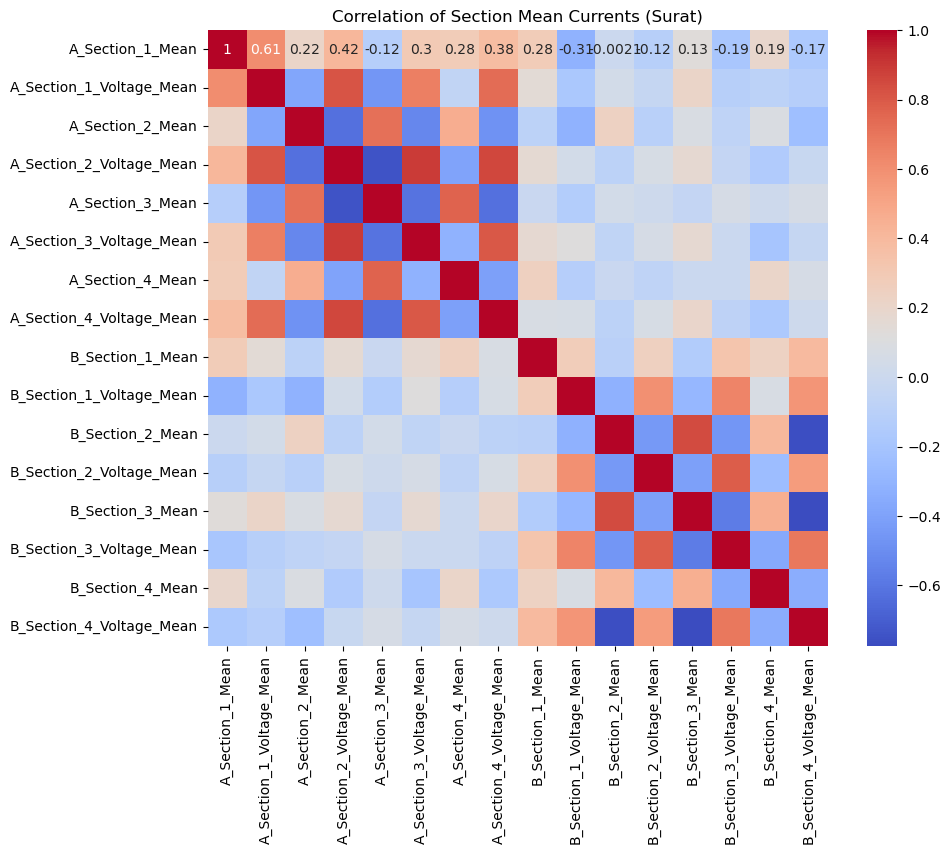

In [4]:
# Enhanced visualization for deeper insights

# 1. Distribution of mean current for each section (A & B) for the selected site
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sections = ['A_Section_1_Mean', 'A_Section_2_Mean', 'A_Section_3_Mean', 'A_Section_4_Mean']
for i, section in enumerate(sections):
    sns.histplot(site_data[section], kde=True, ax=axes[i//2, i%2], color='skyblue')
    axes[i//2, i%2].set_title(f'Distribution of {section} ({site})')
    axes[i//2, i%2].set_xlabel('Current (A)')
plt.tight_layout()
plt.show()

# 2. Boxplot of mean current by direction for each section
plt.figure(figsize=(12, 6))
sns.boxplot(data=site_data, x='Direction', y='A_Section_1_Mean')
plt.title(f'A_Section_1_Mean by Direction ({site})')
plt.ylabel('Current (A)')
plt.show()

# 3. Time series plot of mean current for all sections (A & B)
plt.figure(figsize=(18, 8))
for section in ['A_Section_1_Mean', 'A_Section_2_Mean', 'A_Section_3_Mean', 'A_Section_4_Mean']:
    plt.plot(site_data['Time'], site_data[section], label=section)
for section in ['B_Section_1_Mean', 'B_Section_2_Mean', 'B_Section_3_Mean', 'B_Section_4_Mean']:
    plt.plot(site_data['Time'], site_data[section], linestyle='--', label=section)
plt.legend()
plt.title(f'Time Series of Section Mean Currents ({site})')
plt.xlabel('Time')
plt.ylabel('Current (A)')
plt.show()

# 4. Correlation heatmap for section means (A & B)
mean_cols = [col for col in site_data.columns if '_Mean' in col and 'Section' in col]
plt.figure(figsize=(10, 8))
sns.heatmap(site_data[mean_cols].corr(), annot=True, cmap='coolwarm')
plt.title(f'Correlation of Section Mean Currents ({site})')
plt.show()

## Direction Performance Analysis 

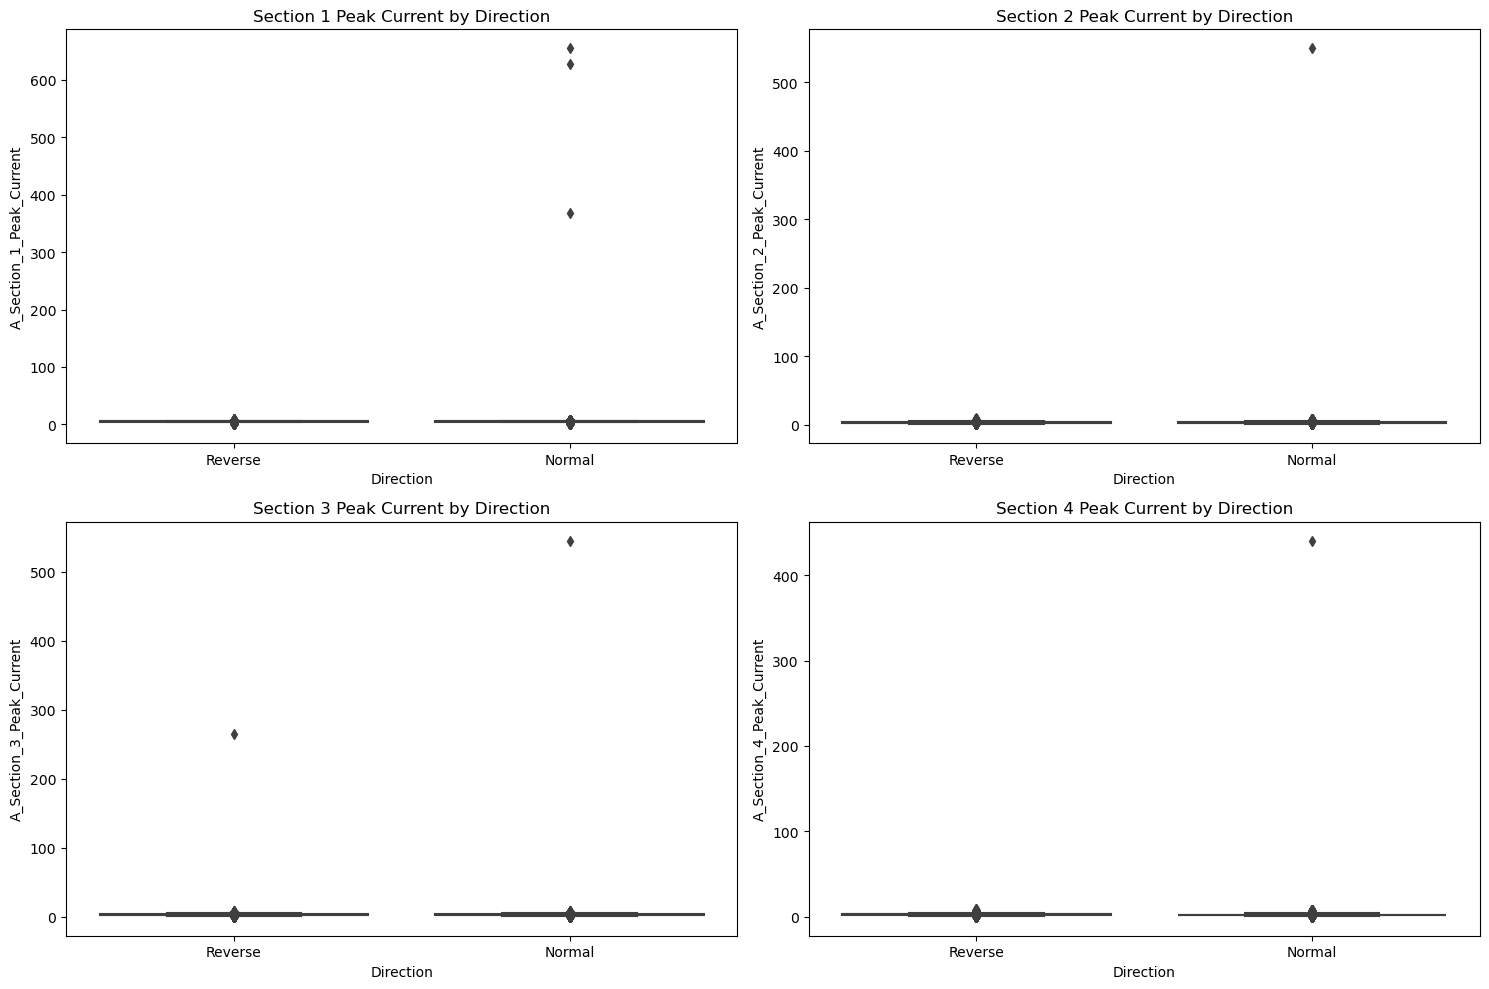

In [6]:
# Compare Normal vs Reverse operations
direction_analysis = df.groupby('Direction').agg({
    'A_Section_1_Peak_Current': ['mean', 'std'],
    'A_Section_2_Peak_Current': ['mean', 'std'],
    'A_Section_3_Peak_Current': ['mean', 'std'],
    'A_Section_4_Peak_Current': ['mean', 'std'],
    'Total Samples A': ['mean', 'std']
})

# Plot directional differences
fig, axes = plt.subplots(2, 2, figsize=(15,10))
for i, section in enumerate(['1', '2', '3', '4']):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df, x='Direction', y=f'A_Section_{section}_Peak_Current', ax=ax)
    ax.set_title(f'Section {section} Peak Current by Direction')
plt.tight_layout()
plt.show()

## temporal analysis 

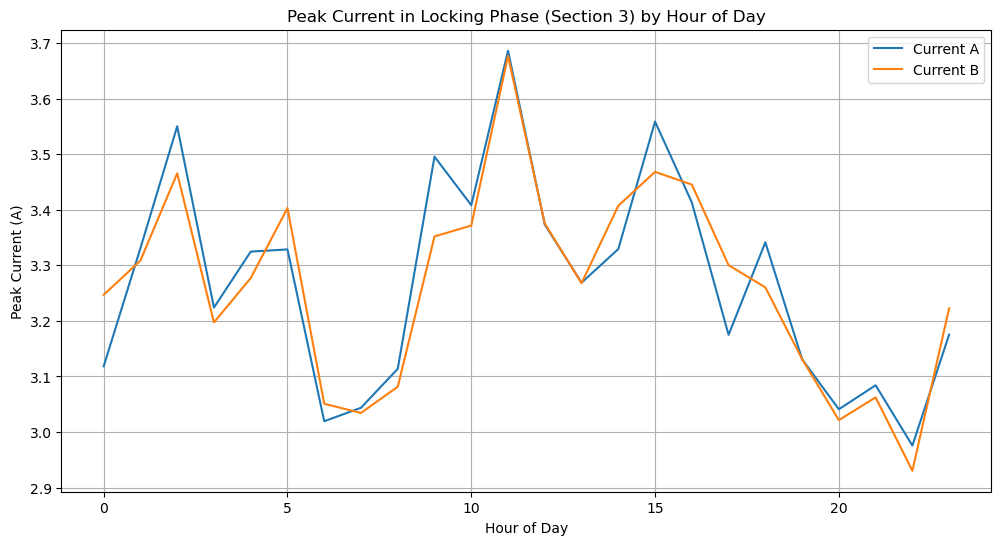

In [7]:
# Analyze by time of day
hourly_analysis = df.groupby('Hour').agg({
    'A_Section_3_Peak_Current': 'mean',
    'B_Section_3_Peak_Current': 'mean',
    'Total Samples A': 'mean'
}).reset_index()

plt.figure(figsize=(12,6))
plt.plot(hourly_analysis['Hour'], hourly_analysis['A_Section_3_Peak_Current'], label='Current A')
plt.plot(hourly_analysis['Hour'], hourly_analysis['B_Section_3_Peak_Current'], label='Current B')
plt.xlabel('Hour of Day')
plt.ylabel('Peak Current (A)')
plt.title('Peak Current in Locking Phase (Section 3) by Hour of Day')
plt.legend()
plt.grid()
plt.show()

## Anomaly Detection 

In [8]:
# Calculate z-scores to find anomalies
for section in ['1', '2', '3', '4']:
    df[f'A_Section_{section}_ZScore'] = (
        (df[f'A_Section_{section}_Peak_Current'] - df[f'A_Section_{section}_Peak_Current'].mean()) / 
        df[f'A_Section_{section}_Peak_Current'].std()
    )
    df[f'B_Section_{section}_ZScore'] = (
        (df[f'B_Section_{section}_Peak_Current'] - df[f'B_Section_{section}_Peak_Current'].mean()) / 
        df[f'B_Section_{section}_Peak_Current'].std()
    )

# Flag anomalies (z-score > 3)
df['Anomaly'] = False
for section in ['1', '2', '3', '4']:
    df['Anomaly'] = df['Anomaly'] | (abs(df[f'A_Section_{section}_ZScore']) > 3)
    df['Anomaly'] = df['Anomaly'] | (abs(df[f'B_Section_{section}_ZScore']) > 3)

# Analyze anomalies
anomalies = df[df['Anomaly']]
print(f"Found {len(anomalies)} anomalous operations")
print(anomalies.groupby(['Site Name', 'Point Machine Name']).size())

Found 8 anomalous operations
Site Name  Point Machine Name
Bhestan    PT-121/122            1
Karambeli  PT-101/102            1
           PT-119/120            5
Vaitarna   PT101/102             1
dtype: int64


In [9]:
anomalies = df[df['Anomaly']]
anomalies

,Time,Site Name,Point Machine Name,Direction,Total Samples A,Total Samples B,A_Section_1_Start,A_Section_1_End,A_Section_1_Min,A_Section_1_Max,...,Month,A_Section_1_ZScore,B_Section_1_ZScore,A_Section_2_ZScore,B_Section_2_ZScore,A_Section_3_ZScore,B_Section_3_ZScore,A_Section_4_ZScore,B_Section_4_ZScore,Anomaly
20672,2025-02-09 05:38:35,Bhestan,PT-121/122,Normal,254,16,0,62,0.0,655.3,...,2,119.125435,0.334267,1.339849,0.106771,0.170218,27.912462,0.429301,25.378570,True
27745,2025-02-09 00:39:06,Karambeli,PT-101/102,Normal,79,9,0,18,0.0,5.6,...,2,0.056471,50.300560,-0.174674,154.246784,-0.350696,0.135981,0.125734,-0.901241,True
27898,2024-08-23 09:19:16,Karambeli,PT-119/120,Reverse,79,250,0,18,0.0,3.7,...,8,-0.291737,115.330220,-0.269331,-0.281797,-0.669032,-0.327870,-0.519346,-0.244246,True
27956,2024-09-03 13:43:25,Karambeli,PT-119/120,Normal,112,199,0,27,0.0,3.8,...,9,-0.273411,-0.323184,-0.427094,-0.184655,-0.524333,-0.273299,166.025049,-0.441344,True
28179,2024-10-26 11:15:13,Karambeli,PT-119/120,Normal,170,79,0,41,0.0,368.6,...,10,66.582612,-0.303848,172.543947,-0.233226,156.820533,172.251935,-0.633184,167.289547,True
28189,2024-10-26 11:50:44,Karambeli,PT-119/120,Normal,139,182,0,33,0.0,3.5,...,10,-0.328391,125.559388,-0.237779,84.474567,-0.553273,-0.327870,-0.595238,-0.441344,True
28467,2024-12-11 16:20:18,Karambeli,PT-119/120,Normal,375,7,0,92,0.0,627.2,...,12,113.975615,-0.999972,0.109299,0.932478,0.054460,0.190552,-0.215779,0.379900,True
32595,2025-01-01 09:39:47,Vaitarna,PT101/102,Reverse,102,168,0,24,0.0,6.2,...,1,0.166432,0.082888,-0.174674,0.398197,75.673760,0.463405,0.125734,0.511299,True
